[2026-07-20 17:10:40] [info     ] 计算因子，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-20 17:10:41] [info     ] 1. 提取大容量分钟 K 线足迹并进行截面聚合 (自 2022-11-17 00:00:00 起)...
[2026-07-20 17:11:04] [info     ] 2. 提取日线大宽表并融合微观特征...
[2026-07-20 17:11:24] [info     ] 流速特征矩阵构建完毕, 总行数: 290580, 耗时: 43.35s

[XGBoost 特征权重]
                          feature  importance
5      price_percentile_252d_rank    0.193757
0  smart_net_buy_ratio_delta_rank    0.180917
1             s_factor_delta_rank    0.151336
6                 market_cap_rank    0.147530
2             momentum_delta_rank    0.126207
3             ma60_deviation_rank    0.105155
4           volume_ratio_20d_rank    0.095098
[2026-07-20 17:12:20] [info     ] 1. 提取大容量分钟 K 线足迹并进行截面聚合 (自 2023-11-17 00:00:00 起)...
[2026-07-20 17:12:42] [info     ] 2. 提取日线大宽表并融合微观特征...
[2026-07-20 17:12:58] [info     ] 流速特征矩阵构建完毕, 总行数: 291793, 耗时: 38.18s
[2026-07-20 17:13:02] [info     ] 策略计算完成，总耗时: 140.61 秒
[2026-07-20 17:13:02] [info     ] 读取因子库，区间：2024-01-

时段,IC
2024-01-15~2024-02-08,0.0170
2024-09-24~2024-10-08,0.0370

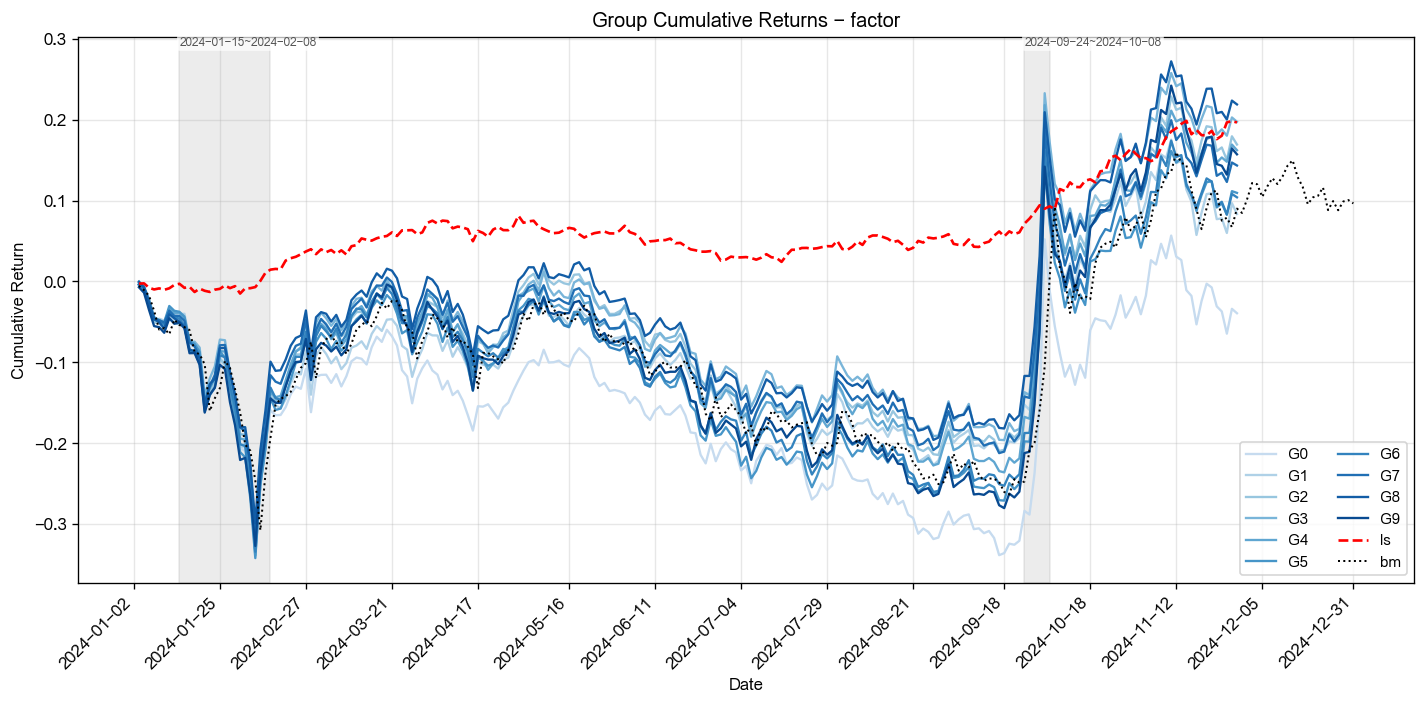
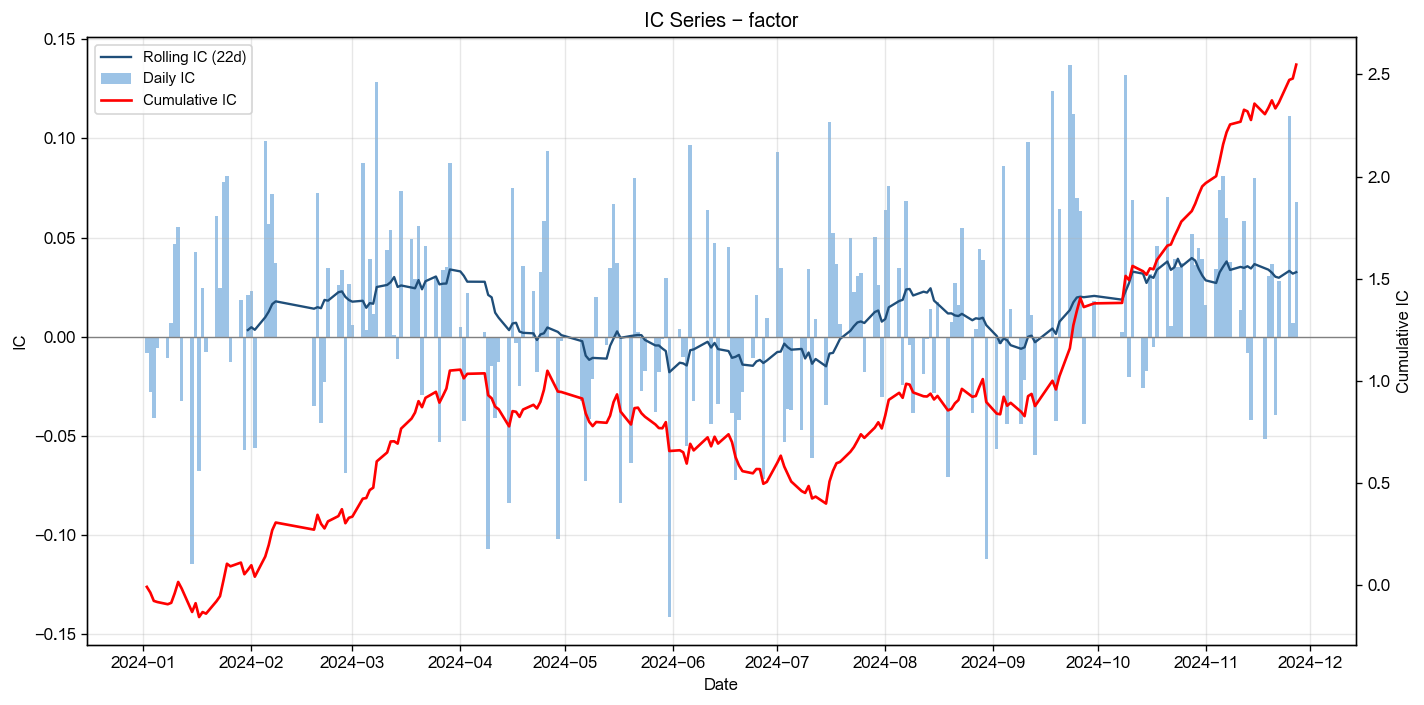
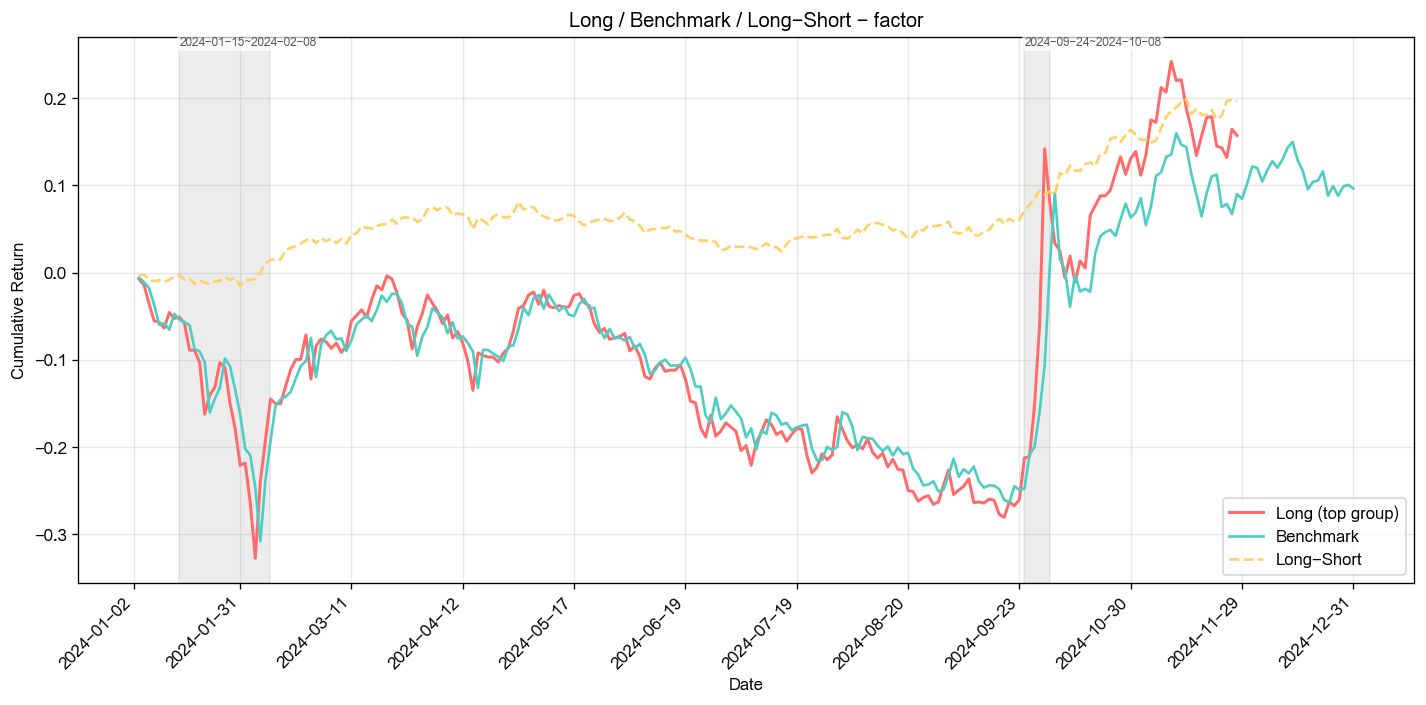
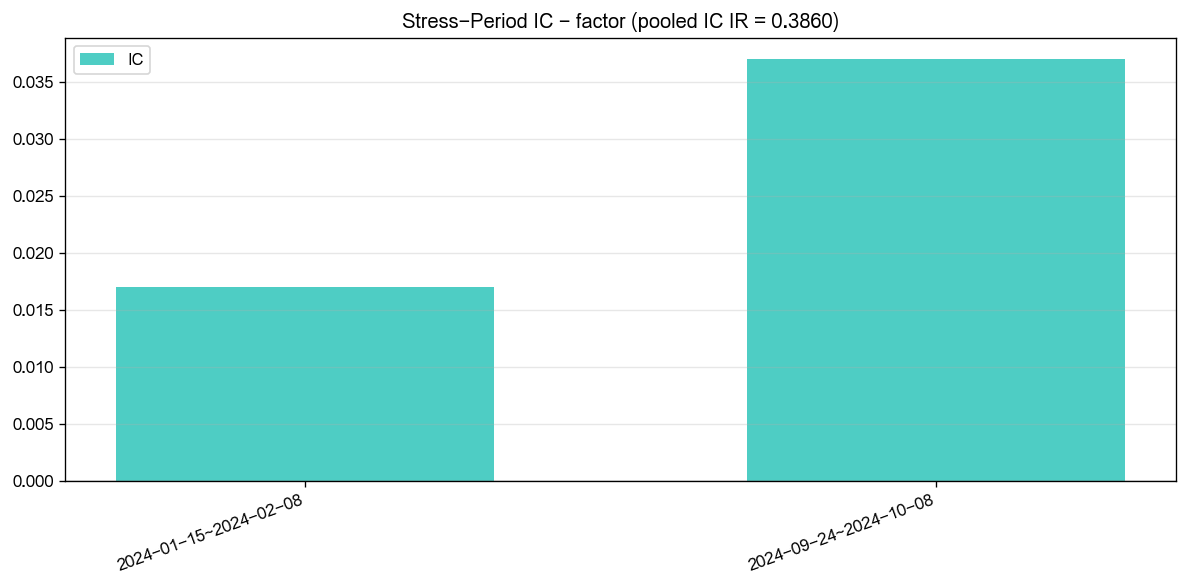
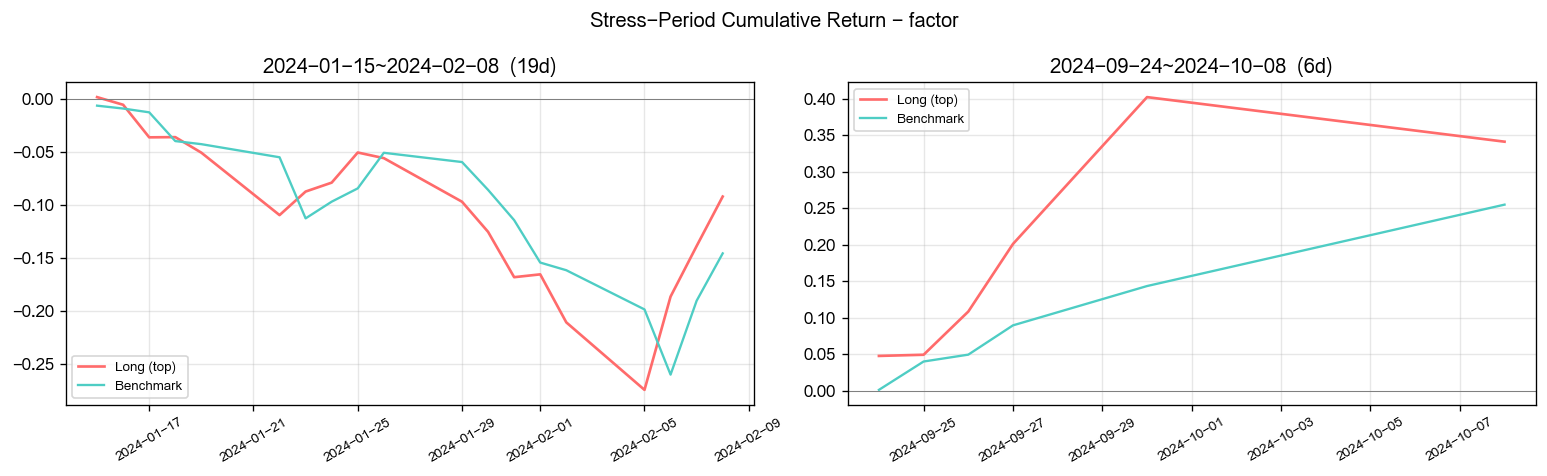

[2026-07-20 17:13:34] [info     ] ========== 因子池回归 ==========
[2026-07-20 17:13:34] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-20 17:13:40] [info     ] 获取收益率数据, 耗时: 5.8326 秒
[2026-07-20 17:13:41] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.3493 秒
[2026-07-20 17:13:41] [info     ] 统计 回归结果, 耗时: 0.025 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.8977,0.0437,0.0230,1.0000
2,amount,1.6950,0.0187,0.0110,0.9000
3,netflow_amount_rate_main,1.5539,0.0100,0.0064,1.0000
4,gross_profit_rate_ttm,1.5236,0.0069,0.0046,1.0000
5,netflow_amount_main,1.5088,0.0252,0.0167,1.0000
6,net_profit_rate_ttm,1.4760,0.0040,0.0027,0.8000
7,bias_20,1.4118,0.0293,0.0208,0.9000
8,cci_14,1.3729,0.0337,0.0246,1.0000
9,pb,1.3548,0.0095,0.0070,0.9000
10,volume,1.3216,0.0135,0.0102,1.0000

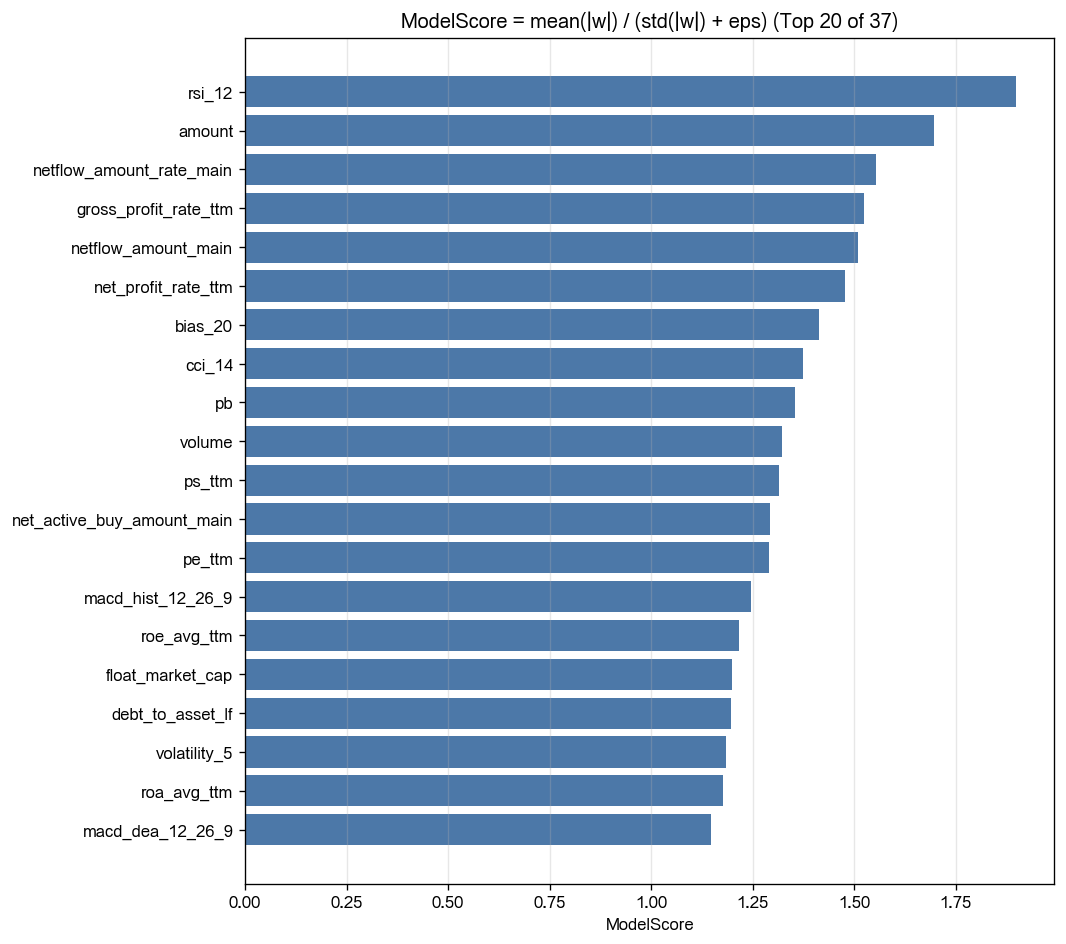
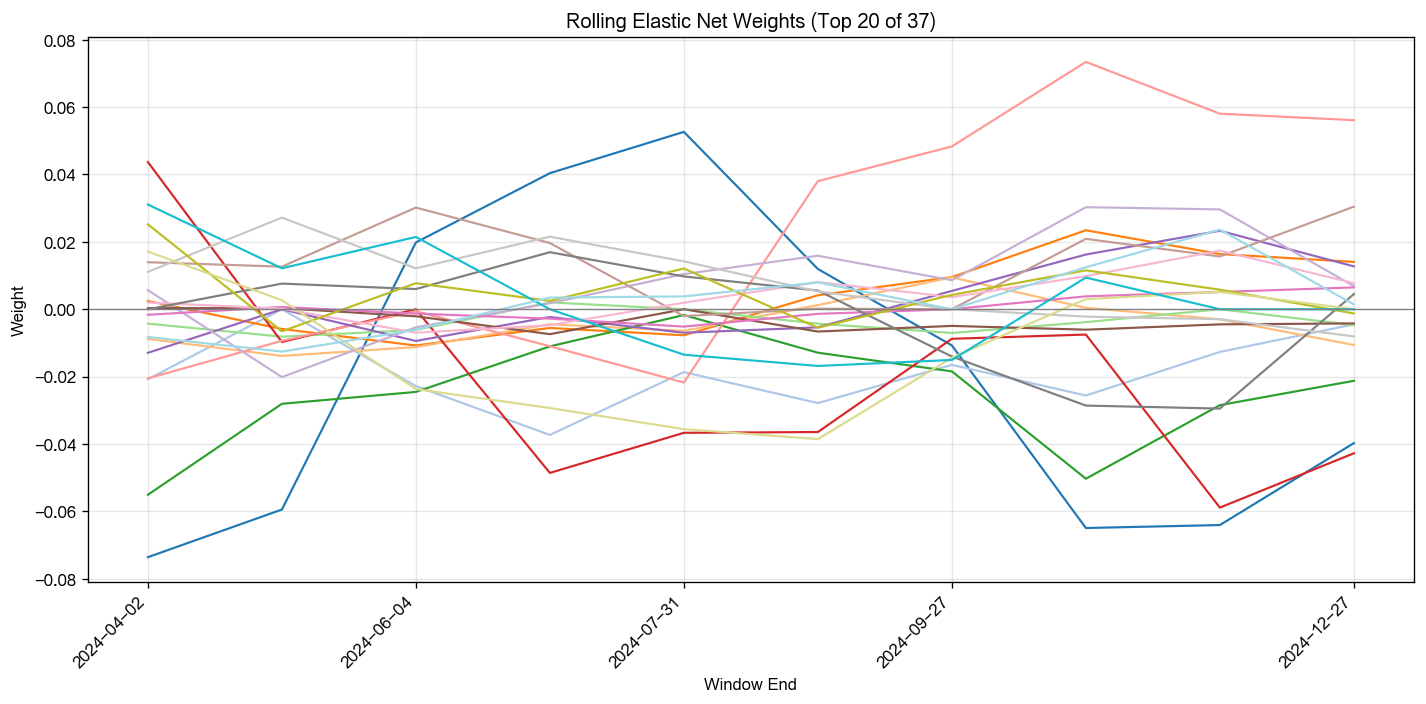
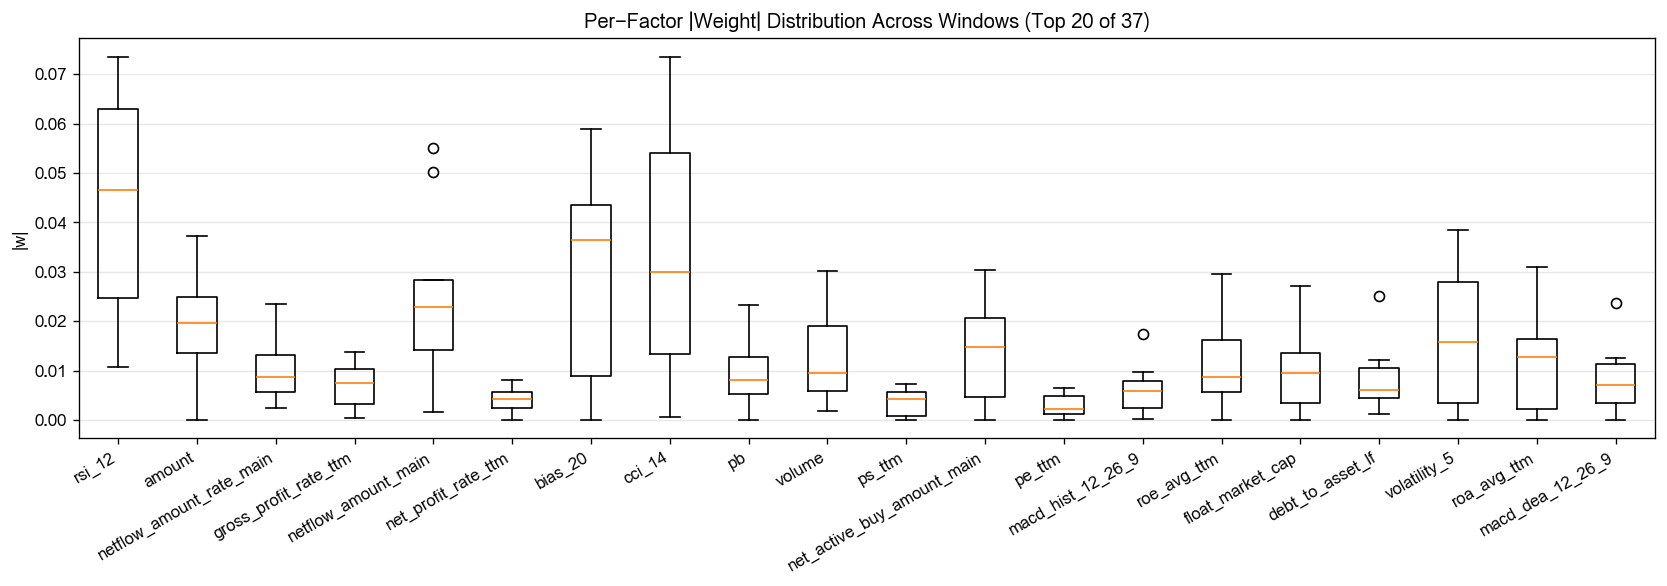
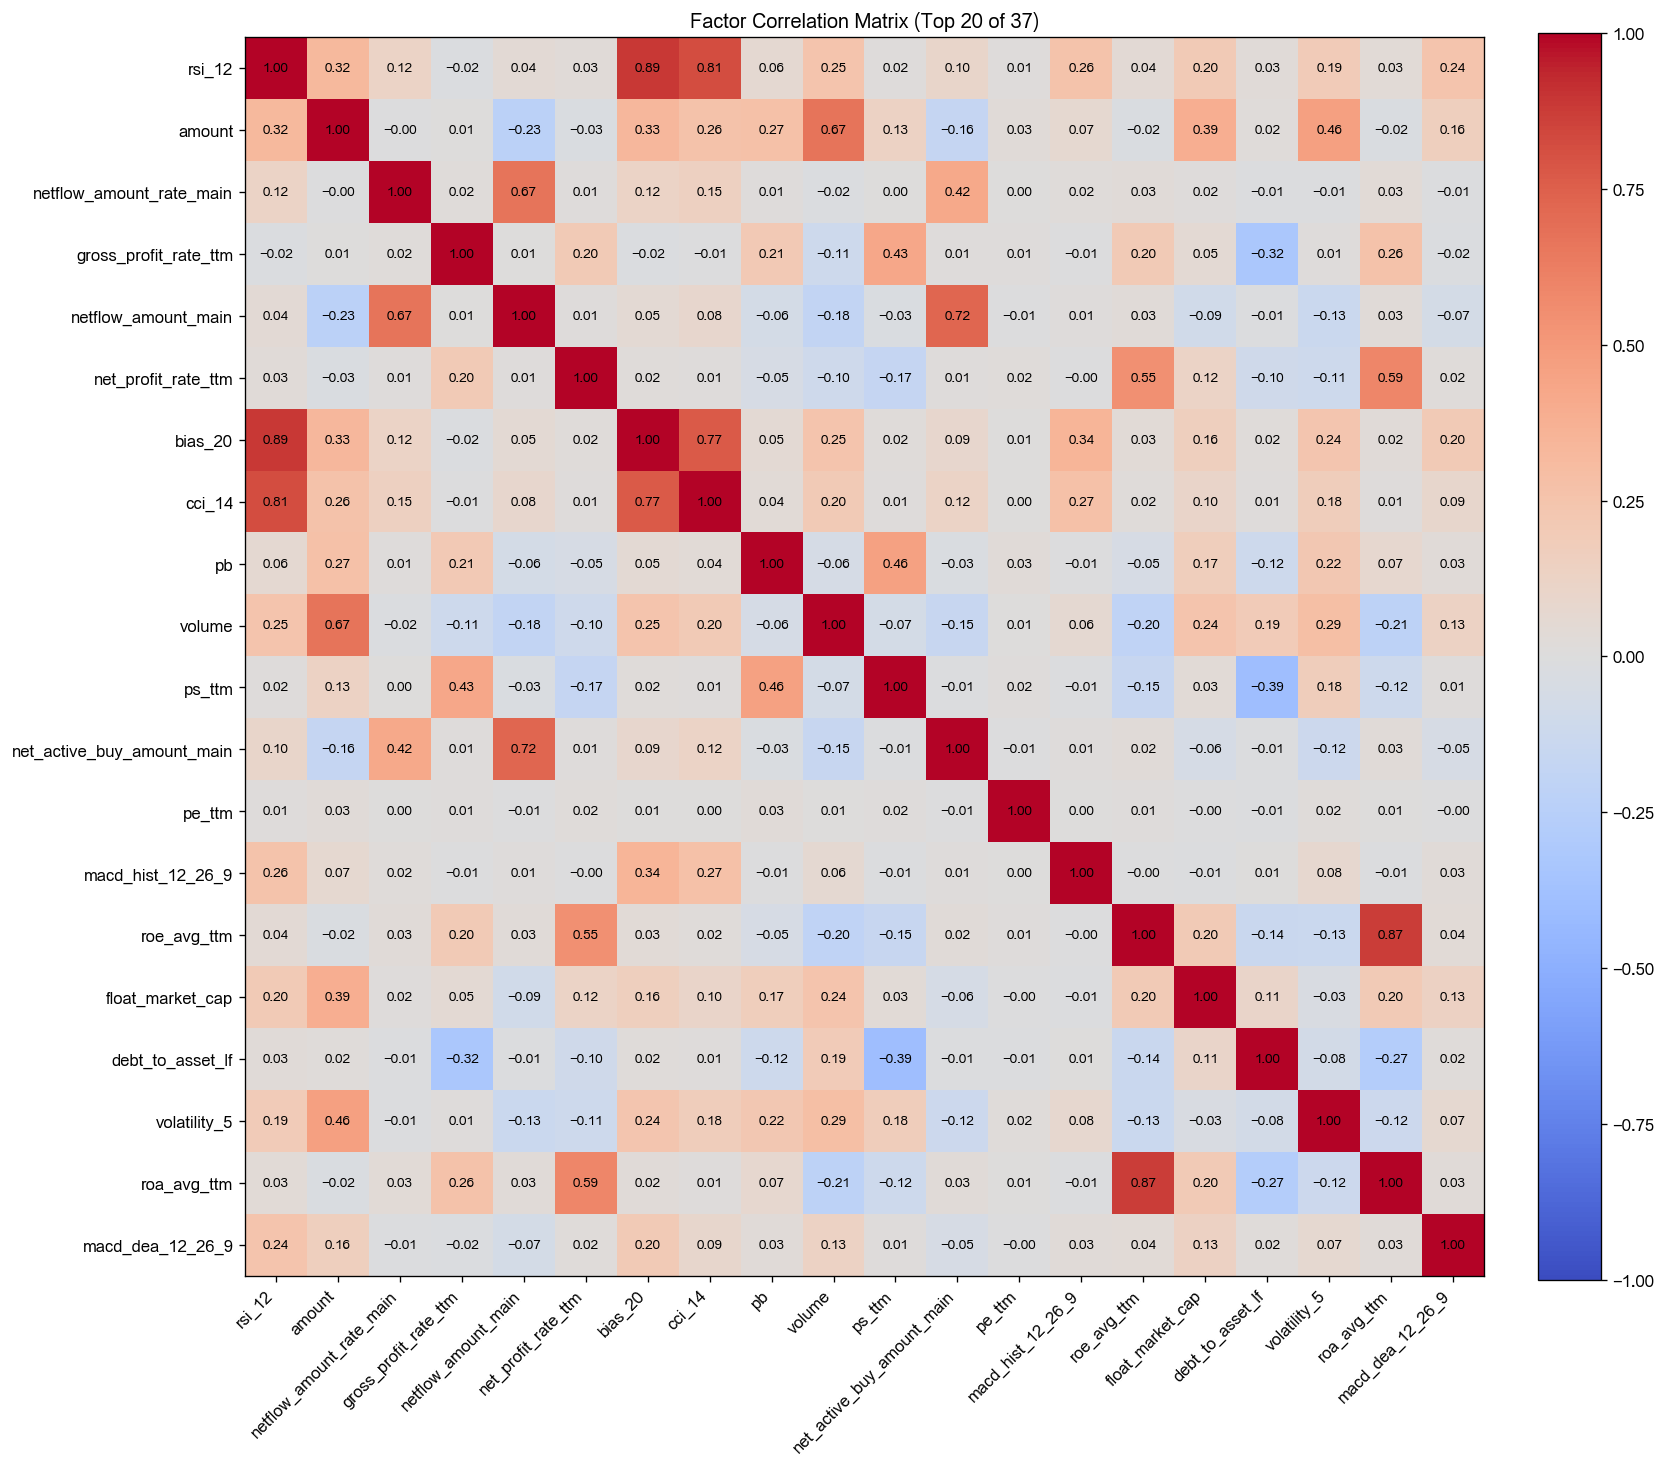

[2026-07-20 17:13:43] [warning  ] 返回的Outputs实例(size=34904191) 大于 64K, 将不会被缓存
[2026-07-20 17:13:43] [info     ] bigalpha_eval.v4 运行完成 [38.796s].


In [1]:
def main(datasources, start_date, end_date):
    import time
    import numpy as np
    import pandas as pd
    import dai
    import xgboost as xgb
    import structlog
    import gc

    logger = structlog.get_logger()
    t0 = time.time()

    EXPERIMENT = "SMART_MONEY_REVERSAL_ALPHA"

    TRAIN_START = "2023-01-01 00:00:00"
    TRAIN_END = "2023-12-31 23:59:59"
    LOOKBACK_DAYS = 252 
    
    bar1m_table = datasources.get("bar1m", "bigalpha_2026_stock_bar1m")
    bar1d_table = datasources.get("bar1d", "bigalpha_2026_bar1d")

    # =========================================================================
    # 核心特征注册表 (全盘 Delta 边际流速特征)
    # =========================================================================
    def get_feature_columns():
        return [
            "smart_net_buy_ratio_delta_rank",  # Index 0: 机构净买入流速
            "s_factor_delta_rank",             # Index 1: smart money 成本偏移流速
            "momentum_delta_rank",             # Index 2: 动量流速 
            "ma60_deviation_rank",             # Index 3: 中期趋势基准乖离
            "volume_ratio_20d_rank",           # Index 4: 量能缩放比
            "price_percentile_252d_rank",      # Index 5: 价格历史分位 
            "market_cap_rank"                  # Index 6: 截面市值
        ]

    feature_cols = get_feature_columns()

    # =========================================================================
    # 数据提取：拉伸高频窗口以支持长短双均线 (MA5 & MA20)
    # =========================================================================
    def build_features(sd, ed, need_label=True):
        build_t0 = time.time()
        
        query_start_daily = (pd.to_datetime(sd) - pd.Timedelta(days=LOOKBACK_DAYS + 40)).strftime("%Y-%m-%d %H:%M:%S")
        query_start_1m = (pd.to_datetime(sd) - pd.Timedelta(days=45)).strftime("%Y-%m-%d %H:%M:%S") 
        
        query_end = pd.to_datetime(ed)
        if need_label:
            query_end = query_end + pd.Timedelta(days=15)
        query_end = query_end.strftime("%Y-%m-%d %H:%M:%S")

        logger.info(f"1. 提取大容量分钟 K 线足迹并进行截面聚合 (自 {query_start_1m} 起)...")
        
        sql_1m = f"""
        WITH min_ranked AS (
            SELECT
                date_trunc('day', date)::DATE AS date,
                instrument,
                open, close, volume, amount,
                PERCENT_RANK() OVER (PARTITION BY date_trunc('day', date)::DATE, instrument ORDER BY volume DESC) as vol_rank
            FROM {bar1m_table}
            WHERE date >= '{query_start_1m}' AND date <= '{query_end}'
        )
        SELECT
            date, instrument,
            SUM(CASE WHEN vol_rank <= 0.2 THEN amount ELSE 0 END) / 
                (SUM(CASE WHEN vol_rank <= 0.2 THEN volume ELSE 0 END) + 1e-8) AS vwap_smart, -- smart money 成本价
            
            SUM(CASE WHEN vol_rank <= 0.2 AND close > open THEN amount
                     WHEN vol_rank <= 0.2 AND close < open THEN -amount ELSE 0 END) / 
                (SUM(CASE WHEN vol_rank <= 0.2 THEN amount ELSE 0 END) + 1e-8) AS smart_net_buy_ratio -- smart money 净买入
        FROM min_ranked
        GROUP BY date, instrument
        """
        df_smart = dai.query(sql_1m, compression=True).df()
        df_smart["date"] = pd.to_datetime(df_smart["date"])
        df_smart["instrument"] = df_smart["instrument"].astype(str)

        logger.info(f"2. 提取日线大宽表并融合微观特征...")
        sql_daily = f"""
        SELECT 
            d.date, d.instrument, d.open, d.high, d.low, d.close, d.volume, d.amount, d.turn,
            s.st_status, s.suspended, b.list_date,
            
            (d.amount / (d.volume + 1e-8)) AS vwap_daily, -- 日线成交均价
            MIN(d.close) OVER (PARTITION BY d.instrument ORDER BY d.date ROWS BETWEEN 252 PRECEDING AND 0 PRECEDING) AS min_close_252d,
            MAX(d.close) OVER (PARTITION BY d.instrument ORDER BY d.date ROWS BETWEEN 252 PRECEDING AND 0 PRECEDING) AS max_close_252d,
            AVG(d.volume) OVER (PARTITION BY d.instrument ORDER BY d.date ROWS BETWEEN 20 PRECEDING AND 0 PRECEDING) AS volume_ma20,
            AVG(d.close) OVER (PARTITION BY d.instrument ORDER BY d.date ROWS BETWEEN 60 PRECEDING AND 0 PRECEDING) AS ma60,
            LEAD(d.open, 1) OVER (PARTITION BY d.instrument ORDER BY d.date) AS next_1d_open,
            LEAD(d.close, 3) OVER (PARTITION BY d.instrument ORDER BY d.date) AS next_3d_close
        FROM {bar1d_table} d
        LEFT JOIN cn_stock_status s ON d.date = s.date AND d.instrument = s.instrument
        LEFT JOIN cn_stock_basic_info b ON d.instrument = b.instrument
        WHERE d.date >= '{query_start_daily}' AND d.date <= '{query_end}'
        """
        df = dai.query(sql_daily, compression=True).df()
        df["date"] = pd.to_datetime(df["date"])
        df["list_date"] = pd.to_datetime(df["list_date"])
        df["instrument"] = df["instrument"].astype(str)
        
        sql_cap = f"SELECT change_date AS date, instrument, float_a FROM cn_stock_capital WHERE change_date >= '2020-01-01'"
        df_cap = dai.query(sql_cap, compression=True).df()
        df_cap["date"] = pd.to_datetime(df_cap["date"])
        df_cap["instrument"] = df_cap["instrument"].astype(str)
        
        df = df.sort_values('date').reset_index(drop=True)
        df_cap = df_cap.sort_values('date').reset_index(drop=True)
        df = pd.merge_asof(df, df_cap, on='date', by='instrument', direction='backward')
        
        df = pd.merge(df, df_smart, on=['date', 'instrument'], how='left')
        
        del df_cap, df_smart
        gc.collect() # 释放内存

        num_cols = ["close", "volume", "amount", "vwap_daily", "vwap_smart", "smart_net_buy_ratio",
                    "min_close_252d", "max_close_252d", "volume_ma20", "ma60", "float_a"]
        for c in num_cols:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors="coerce").astype(float)

        # =========================================================================
        # Delta 边际流速特征构建 
        # =========================================================================
        df['market_cap'] = df['float_a'] * df['close']
        
        df["s_factor_daily"] = df["vwap_smart"] / (df["vwap_daily"] + 1e-8) # smart money 成本偏移因子（相对于日线成交均价）
        
        df = df.sort_values(['instrument', 'date']).reset_index(drop=True)
        g = df.groupby("instrument")
        
        df["s_factor_ma5"] = g["s_factor_daily"].transform(lambda x: x.rolling(5, min_periods=2).mean()) # smart money 成本偏移5日均线
        df["s_factor_ma20"] = g["s_factor_daily"].transform(lambda x: x.rolling(20, min_periods=10).mean()) # smart money 成本偏移20日均线
        
        df["smart_net_buy_ratio_ma5"] = g["smart_net_buy_ratio"].transform(lambda x: x.rolling(5, min_periods=2).mean()) # smart money 净买入流速5日均线
        df["smart_net_buy_ratio_ma20"] = g["smart_net_buy_ratio"].transform(lambda x: x.rolling(20, min_periods=10).mean()) # smart money 净买入流速20日均线

        df["s_factor_delta"] = df["s_factor_ma5"] - df["s_factor_ma20"] # smart money 成本偏移Delta（短期成本偏移与中期成本偏移的差值）
        df["smart_net_buy_ratio_delta"] = df["smart_net_buy_ratio_ma5"] - df["smart_net_buy_ratio_ma20"] # smart money 净买入流速Delta

        df['ret_5d'] = df['close'] / (g['close'].shift(5) + 1e-8) - 1 # 5日收益率
        df['ret_20d'] = df['close'] / (g['close'].shift(20) + 1e-8) - 1 # 20日收益率
        df["momentum_delta"] = df['ret_5d'] - df['ret_20d'] # 动量Delta

        df["ma60_deviation"] = df["close"] / (df["ma60"] + 1e-8) - 1 # 60日均线乖离率
        df["price_percentile_252d"] = (df["close"] - df["min_close_252d"]) / (df["max_close_252d"] - df["min_close_252d"] + 1e-8) # 一年价格分位数
        df["volume_ratio_20d"] = df["volume"] / (df["volume_ma20"] + 1e-8) # 20日量能缩放比（当日成交量 / 20日均量）

        rank_cols = ["smart_net_buy_ratio_delta", "s_factor_delta", "momentum_delta", 
                     "ma60_deviation", "volume_ratio_20d", "price_percentile_252d", "market_cap"]
        for col in rank_cols:
            df[f"{col}_rank"] = df.groupby("date")[col].transform(lambda x: x.rank(pct=True)) # 计算全市场股票的截面分位数排名

        df['list_days'] = (df['date'] - df['list_date']).dt.days # 计算上市天数，为了过滤新股、退市股和小盘股
        df['is_valid'] = (
            (df['st_status'] == 0) & 
            (df['suspended'] == 0) & 
            (df['list_days'] > 365) & 
            (df['market_cap_rank'] > 0.15)
        ).astype(bool)

        if need_label:
            df['daily_ret'] = g['close'].pct_change()
            df['volatility_20d'] = g['daily_ret'].transform(lambda x: x.rolling(20).std())
            
            df["ret_forward_3d"] = df["next_3d_close"] / (df["next_1d_open"] + 1e-8) - 1
            is_limit_up = (df["next_1d_open"] / (df["close"] + 1e-8) - 1) > 0.095 # 次日开盘涨停则无法买入
            df.loc[is_limit_up, "ret_forward_3d"] = np.nan # 如果次日开盘涨停，则无法买入，未来3日收益率设为NaN
            
            df["market_ret_forward_3d"] = df.groupby("date")["ret_forward_3d"].transform("mean")
            df["label_raw"] = df["ret_forward_3d"] - df["market_ret_forward_3d"]
            
            df['label'] = df['label_raw'] / (df['volatility_20d'] + 1e-4)

        df = df[(df["date"] >= pd.to_datetime(sd)) & (df["date"] <= pd.to_datetime(ed))].copy() 

        for c in feature_cols + (["label"] if need_label else []):
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors="coerce").astype(float)
                df[c] = df[c].replace([np.inf, -np.inf], np.nan)

        logger.info(f"流速特征矩阵构建完毕, 总行数: {len(df)}, 耗时: {round(time.time() - build_t0, 2)}s") 
        return df.reset_index(drop=True)

    # =========================================================================
    # 模型训练层
    # =========================================================================
    def train_model(train_df):
        train_df = train_df[train_df['is_valid']].dropna(subset=["label"]).copy()
        train_df[feature_cols] = train_df[feature_cols].fillna(0) 

        # --- 设置线性条件 ---
        # 0: smart_net_buy_ratio_delta_rank -> +1 (聪明钱加速流入)
        # 1: s_factor_delta_rank            -> +1 (大资金上攻，高位护盘)
        # 2: momentum_delta_rank            -> -1 (动量短线急拉触发均值回归)
        # 3: ma60_deviation_rank            -> -1 (乖离过高，面临均值回归)
        # 4: volume_ratio_20d_rank          -> -1 (异常放量=主力出货/筹码松动)
        # 5: price_percentile_252d_rank     -> -1 (高位票=补跌雷区，低位票=抛压真空)
        # 6: market_cap_rank                -> +1 (微盘股危机，资金抱团大市值避险)
        constraints = (1, 1, -1, -1, -1, -1, 1)

        model = xgb.XGBRegressor(
            n_estimators=100,       
            max_depth=3,            
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=30,
            reg_lambda=15.0,        
            tree_method="hist",
            monotone_constraints=constraints,
            n_jobs=-1,
            random_state=42,
        ) 
        model.fit(train_df[feature_cols], train_df["label"]) 
        return model

    # =========================================================================
    # 执行流
    # =========================================================================
    train_df = build_features(TRAIN_START, TRAIN_END, need_label=True)
    model = train_model(train_df)
    
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)
    print("\n[XGBoost 特征权重]")
    print(importance_df.to_string())

    test_df = build_features(start_date, end_date, need_label=False)
    test_df[feature_cols] = test_df[feature_cols].fillna(0) 
    
    test_df["predicted_factor"] = model.predict(test_df[feature_cols]) 

    # =========================================================================
    # 极值映射打分法
    # =========================================================================
    valid_mask = test_df['is_valid'] == True
    
    test_df.loc[valid_mask, 'limit_rank'] = test_df[valid_mask].groupby('date')['predicted_factor'].rank(pct=True) 
    test_df.loc[valid_mask, 'factor_raw'] = (test_df.loc[valid_mask, 'limit_rank'] - 0.5) * 2 # 映射到 [-1, 1] 区间
    
    test_df.loc[~valid_mask, 'factor_raw'] = 0 # 无效股票因子设为0，避免覆盖率不足
    test_df['factor'] = test_df['factor_raw']

    # =========================================================================
    # 对齐并提交
    # =========================================================================
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df() 

    stk_pool["date"] = pd.to_datetime(stk_pool["date"])
    stk_pool["instrument"] = stk_pool["instrument"].astype(str)
    test_df["instrument"] = test_df["instrument"].astype(str)

    result = pd.merge(
        stk_pool,
        test_df[["date", "instrument", "factor"]],
        how="left",
        on=["date", "instrument"],
    ) 

    result["factor"] = result["factor"].replace([np.inf, -np.inf], np.nan)
    result["factor"] = result["factor"].fillna(0)
    result = result.drop_duplicates(subset=["date", "instrument"], keep="last").reset_index(drop=True) 

    logger.info(f"策略计算完成，总耗时: {round(time.time() - t0, 2)} 秒")
    return result[["date", "instrument", "factor"]]


# ========================
# BigQuant的计算执行行
# ========================
if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'bar1d': 'bigalpha_2026_bar1d'
    }
    
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )